In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('creditcard.csv')

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:

print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


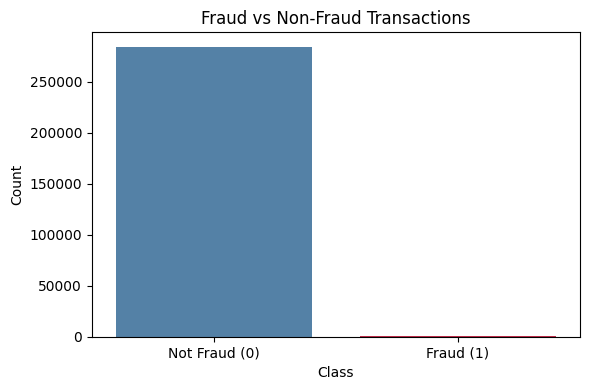

In [4]:

fraud_count = df['Class'].value_counts()
print("Class distribution:")
print(fraud_count)
print(f"\nFraud percentage: {fraud_count[1]/len(df)*100:.4f}%")


plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['steelblue','crimson'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.xticks([0,1], ['Not Fraud (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

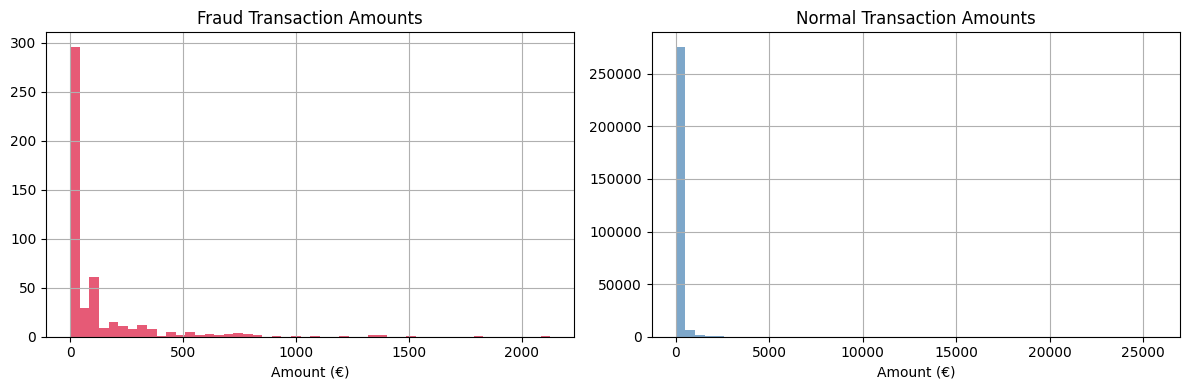


Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Amount distribution for fraud
df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[0], color='crimson', alpha=0.7)
axes[0].set_title('Fraud Transaction Amounts')
axes[0].set_xlabel('Amount (€)')

# Amount distribution for normal
df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('Normal Transaction Amounts')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()

print("\nFraud transactions - Amount stats:")
print(df[df['Class']==1]['Amount'].describe())
print("\nNormal transactions - Amount stats:")
print(df[df['Class']==0]['Amount'].describe())

In [6]:
# Correlation with the fraud label
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top features correlated with fraud:")
print(correlations.head(10))
print("\nBottom features (negative correlation):")
print(correlations.tail(5))

Top features correlated with fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Bottom features (negative correlation):
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Amount', 'Time'], axis=1, inplace=True)
print("✅ Scaling done. Shape:", df.shape)

✅ Scaling done. Shape: (284807, 31)


In [8]:
# Reloading original df with Time & Amount before this step
# These features will simulate real banking feature engineering

# Transaction velocity — how many txns in last 'window'
df_raw = pd.read_csv('creditcard.csv')  # reload original

# Hour of day (Time is in seconds from first transaction)
df_raw['hour'] = (df_raw['Time'] // 3600) % 24

# Velocity: transaction count per hour bucket
velocity = df_raw.groupby('hour')['Amount'].transform('count')
df_raw['txn_velocity_per_hour'] = velocity

# Amount percentile rank (risk signal)
df_raw['amount_rank'] = df_raw['Amount'].rank(pct=True)

# High value flag
df_raw['is_high_value'] = (df_raw['Amount'] > df_raw['Amount'].quantile(0.95)).astype(int)

# Log transform of Amount (reduces skew)
df_raw['log_amount'] = np.log1p(df_raw['Amount'])

print("✅ Feature engineering done")
print(df_raw[['hour','txn_velocity_per_hour','amount_rank','is_high_value','log_amount']].head())

✅ Feature engineering done
   hour  txn_velocity_per_hour  amount_rank  is_high_value  log_amount
0   0.0                   7695     0.859331              0    5.014760
1   0.0                   7695     0.185173              0    1.305626
2   0.0                   7695     0.952101              1    5.939276
3   0.0                   7695     0.832299              0    4.824306
4   0.0                   7695     0.731135              0    4.262539


In [9]:
# Simulate merchant category risk scores
np.random.seed(42)
merchant_risk_map = {i: np.random.uniform(0.01, 0.5) 
                     for i in range(24)}  # one per hour bucket

df_raw['merchant_risk_score'] = df_raw['hour'].map(merchant_risk_map)

print("✅ Merchant risk scores added")
print(df_raw['merchant_risk_score'].describe())

✅ Merchant risk scores added
count    284807.000000
mean          0.219213
std           0.134519
min           0.020086
25%           0.099868
50%           0.189517
75%           0.309808
max           0.485256
Name: merchant_risk_score, dtype: float64


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scale Amount and Time
scaler = StandardScaler()
df_raw['scaled_Amount'] = scaler.fit_transform(df_raw['Amount'].values.reshape(-1,1))
df_raw['scaled_Time'] = scaler.fit_transform(df_raw['Time'].values.reshape(-1,1))

# Drop originals
df_raw.drop(['Amount', 'Time'], axis=1, inplace=True)

# Features & Target
X = df_raw.drop('Class', axis=1)
y = df_raw['Class']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraud in train: {y_train.sum()} | Fraud in test: {y_test.sum()}")

✅ Train: (227845, 36) | Test: (56962, 36)
Fraud in train: 394 | Fraud in test: 98


In [11]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"✅ After SMOTE:")
print(f"Not Fraud: {sum(y_train_sm==0):,}")
print(f"Fraud:     {sum(y_train_sm==1):,}")

✅ After SMOTE:
Not Fraud: 227,451
Fraud:     227,451
